# 2D Holstein plots

This notebook auto-discovers `*.npz` and `*.xlsx` files under `multiset_202606/2DHolstein`, skips missing or unreadable files, and plots max bond entropy and 2D RMSD for multiset/singleset runs.

In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import to_hex, to_rgb
from matplotlib.lines import Line2D

# Run this notebook either from the repository root or from multiset_202606/2DHolstein.
BASE_DIR = Path.cwd()
if BASE_DIR.name != "2DHolstein_mu64":
    candidate = Path("multiset_202606/2DHolstein_mu64")
    BASE_DIR = candidate if candidate.exists() else BASE_DIR

COUPLINGS = ["weakcoupling", "intermediatecoupling", "strongcoupling"]
METHODS = ["multiset", "singleset"]

# Set TARGET_SIZES = None to plot every discovered square size, including future data.
TARGET_SIZES = [5, 7, 9]

# Default keeps the current 5x5/7x7/9x9 chi=16 comparison; set None to use the largest available bond dimension per case.
# Example: TARGET_BOND_DIMS = [16] keeps only chi=16 files; TARGET_BOND_DIMS = None auto-adds future chi data.
TARGET_BOND_DIMS = [16]

# Match the 1D notebook convention t/(2*pi). Set to 1.0 for raw time_series.
TIME_DIVISOR = 2 * np.pi
XLSX_DT_FALLBACK = 0.1

SAVE_FIGURES = False
FIG_DIR = BASE_DIR / "figures"

COUPLING_LABELS = {
    "weakcoupling": "weak coupling",
    "intermediatecoupling": "intermediate coupling",
    "strongcoupling": "strong coupling",
}

COUPLING_BASE_COLORS = {
    "weakcoupling": "#2474a6",
    "intermediatecoupling": "#d07b18",
    "strongcoupling": "#b73939",
}

@dataclass(frozen=True)
class RunMeta:
    coupling: str
    size: int
    method: str
    bond_dim: Optional[int]
    path: Path

@dataclass
class RunData:
    meta: RunMeta
    time: Optional[np.ndarray] = None
    occupations: Optional[np.ndarray] = None
    max_bond_entropy: Optional[np.ndarray] = None

def parse_square_size_token(token):
    for split in range(1, len(token)):
        left = token[:split]
        right = token[split:]
        if left and right and int(left) == int(right):
            return int(left)
    return None

def parse_square_size(path: Path):
    for part in reversed(path.parts):
        folder_match = re.fullmatch(r"Holstein_2D(\d+)", part)
        if folder_match:
            size = parse_square_size_token(folder_match.group(1))
            if size is not None:
                return size
    match = re.search(r"(?:Holstein|H)(\d+)", path.stem)
    return parse_square_size_token(match.group(1)) if match else None

def parse_bond_dim(path: Path):
    for pattern in [r"_(\d+)bd(?:_|\Z)", r"_2D_[ms](\d+)\Z", r"_[ms](\d+)\Z"]:
        match = re.search(pattern, path.stem)
        if match:
            return int(match.group(1))
    return None

def parse_method(path: Path):
    lowered = path.stem.lower()
    if "multiset" in lowered or re.search(r"(?:_2d)?_m\d+\Z", lowered):
        return "multiset"
    if "singleset" in lowered or re.search(r"(?:_2d)?_s\d+\Z", lowered):
        return "singleset"
    return None

def parse_coupling(path: Path):
    parts = set(path.parts)
    for coupling in COUPLINGS:
        if coupling in parts:
            return coupling
    return None

def path_rank(path: Path):
    rank = 0
    if path.suffix == ".npz":
        rank += 100
    if "plot_Holstein2D" in path.parts:
        rank += 10
    return rank

def discover_run_files(base_dir=BASE_DIR):
    best = {}
    for path in sorted(list(base_dir.rglob("*.npz")) + list(base_dir.rglob("*.xlsx"))):
        coupling = parse_coupling(path)
        method = parse_method(path)
        size = parse_square_size(path)
        if coupling is None or method is None or size is None:
            continue
        if TARGET_SIZES is not None and size not in TARGET_SIZES:
            continue
        bond_dim = parse_bond_dim(path)
        if TARGET_BOND_DIMS is not None and bond_dim not in TARGET_BOND_DIMS:
            continue
        key = (coupling, size, method, bond_dim)
        meta = RunMeta(coupling, size, method, bond_dim, path)
        if key not in best or path_rank(path) > path_rank(best[key].path):
            best[key] = meta
    return sorted(best.values(), key=lambda m: (COUPLINGS.index(m.coupling), m.size, METHODS.index(m.method), m.bond_dim or -1))

def choose_best_per_case(records):
    selected = {}
    for meta in records:
        key = (meta.coupling, meta.size, meta.method)
        current = selected.get(key)
        current_bd = -1 if current is None or current.bond_dim is None else current.bond_dim
        meta_bd = -1 if meta.bond_dim is None else meta.bond_dim
        if current is None or meta_bd > current_bd or (meta_bd == current_bd and path_rank(meta.path) > path_rank(current.path)):
            selected[key] = meta
    return sorted(selected.values(), key=lambda m: (COUPLINGS.index(m.coupling), m.size, METHODS.index(m.method)))

def read_npz(path: Path):
    with np.load(path, allow_pickle=True) as data:
        keys = set(data.files)
        time = np.asarray(data["time_series"], dtype=float) if "time_series" in keys else None
        occupations = None
        for key in ["e_occupations", "electron occupations array", "electron_occupations"]:
            if key in keys:
                occupations = np.asarray(np.real_if_close(data[key]), dtype=float)
                break
        max_bond_entropy = None
        if "S_maxbond" in keys:
            max_bond_entropy = np.asarray(np.real_if_close(data["S_maxbond"]), dtype=float)
        else:
            for key in ["bond_vn_entropy", "bond entropy", "bond_entropy"]:
                if key in keys:
                    arr = np.asarray(np.real_if_close(data[key]), dtype=float)
                    max_bond_entropy = arr if arr.ndim == 1 else np.max(arr, axis=1)
                    break
    return time, occupations, max_bond_entropy

def read_xlsx_occupations(path: Path):
    xls = pd.ExcelFile(path)
    if "populations" in xls.sheet_names:
        df = pd.read_excel(path, sheet_name="populations")
        site_cols = [col for col in df.columns if str(col).startswith("site_")]
        if site_cols:
            time = pd.to_numeric(df["time"], errors="coerce").to_numpy(dtype=float) if "time" in df.columns else None
            occupations = df[site_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
            return time, np.nan_to_num(occupations)
    df = pd.read_excel(path, sheet_name=xls.sheet_names[0], header=None)
    arr = df.apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    keep = ~np.all(np.isnan(arr), axis=1)
    arr = np.nan_to_num(arr[keep])
    time = np.arange(arr.shape[0], dtype=float) * XLSX_DT_FALLBACK
    return time, arr

def load_run(meta: RunMeta):
    try:
        if not meta.path.exists():
            raise FileNotFoundError(meta.path)
        if meta.path.suffix == ".npz":
            time, occupations, max_bond_entropy = read_npz(meta.path)
        elif meta.path.suffix == ".xlsx":
            time, occupations = read_xlsx_occupations(meta.path)
            max_bond_entropy = None
        else:
            return None
        if time is None and occupations is not None:
            time = np.arange(occupations.shape[0], dtype=float) * XLSX_DT_FALLBACK
        return RunData(meta=meta, time=time, occupations=occupations, max_bond_entropy=max_bond_entropy)
    except (FileNotFoundError, KeyError, ValueError, OSError) as exc:
        warnings.warn(f"skip {meta.path}: {exc}")
        return None

def compute_rmsd_2d(occupations, size):
    occupations = np.asarray(occupations, dtype=float)
    nsite = occupations.shape[1]
    if size is None or size * size != nsite:
        inferred = int(round(np.sqrt(nsite)))
        if inferred * inferred != nsite:
            raise ValueError(f"cannot infer square grid from {nsite} sites")
        size = inferred
    yy, xx = np.indices((size, size), dtype=float)
    center = (size - 1) / 2
    dist2 = ((xx - center) ** 2 + (yy - center) ** 2).reshape(-1)
    norm = occupations.sum(axis=1, keepdims=True)
    rho = np.divide(occupations, norm, out=np.zeros_like(occupations), where=norm > 0)
    return np.sqrt((rho * dist2).sum(axis=1))

def plot_time(time):
    return np.asarray(time, dtype=float) / TIME_DIVISOR

def color_shades(base_color, sizes):
    sizes = sorted(sizes)
    rgb = np.array(to_rgb(base_color))
    if len(sizes) == 1:
        weights = [0.0]
    else:
        weights = np.linspace(0.58, 0.0, len(sizes))
    return {size: to_hex(rgb * (1 - w) + np.ones(3) * w) for size, w in zip(sizes, weights)}

def method_linestyle(method):
    return "-" if method == "multiset" else "--"

def method_label(method):
    return "multiset" if method == "multiset" else "singleset"

def maybe_save(fig, filename):
    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")


In [2]:
all_records = discover_run_files(BASE_DIR)
plot_records = choose_best_per_case(all_records)
runs = [run for run in (load_run(meta) for meta in plot_records) if run is not None]

summary = pd.DataFrame([
    {
        "coupling": run.meta.coupling,
        "size": f"{run.meta.size}x{run.meta.size}",
        "method": run.meta.method,
        "bond_dim": run.meta.bond_dim,
        "has_entropy": run.max_bond_entropy is not None,
        "has_occupations": run.occupations is not None,
        "n_time": None if run.time is None else len(run.time),
        "path": str(run.meta.path.relative_to(BASE_DIR)),
    }
    for run in runs
])

display(summary)


,coupling,size,method,bond_dim,has_entropy,has_occupations,n_time,path
0,strongcoupling,5x5,multiset,16,True,True,500,strongcoupling/Holstein_2D55/multiset/H55_2D_m...
1,strongcoupling,5x5,singleset,16,True,True,500,strongcoupling/Holstein_2D55/singleset/H55_2D_...
2,strongcoupling,7x7,multiset,16,True,True,500,strongcoupling/Holstein_2D77/multiset/H77_2D_m...
3,strongcoupling,7x7,singleset,16,True,True,500,strongcoupling/Holstein_2D77/singleset/H77_2D_...


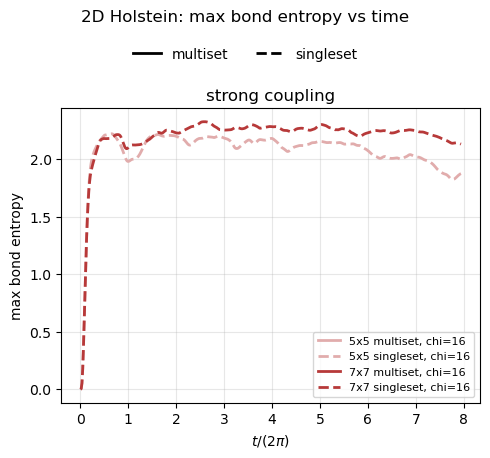

In [3]:
entropy_runs = [run for run in runs if run.time is not None and run.max_bond_entropy is not None]
couplings_present = [c for c in COUPLINGS if any(run.meta.coupling == c for run in entropy_runs)]

if not entropy_runs:
    print("No max bond entropy data found.")
else:
    fig, axes = plt.subplots(1, len(couplings_present), figsize=(5.0 * len(couplings_present), 4.2), sharey=True, squeeze=False)
    axes = axes.ravel()
    for ax, coupling in zip(axes, couplings_present):
        coupling_runs = [run for run in entropy_runs if run.meta.coupling == coupling]
        sizes = sorted({run.meta.size for run in coupling_runs})
        colors = color_shades(COUPLING_BASE_COLORS[coupling], sizes)
        for size in sizes:
            for method in METHODS:
                candidates = [run for run in coupling_runs if run.meta.size == size and run.meta.method == method]
                if not candidates:
                    continue
                run = candidates[0]
                n = min(len(run.time), len(run.max_bond_entropy))
                chi = "" if run.meta.bond_dim is None else f", chi={run.meta.bond_dim}"
                ax.plot(
                    plot_time(run.time[:n]),
                    run.max_bond_entropy[:n],
                    color=colors[size],
                    linestyle=method_linestyle(method),
                    linewidth=2.0,
                    label=f"{size}x{size} {method_label(method)}{chi}",
                )
        ax.set_title(COUPLING_LABELS.get(coupling, coupling))
        ax.set_xlabel(r"$t/(2\pi)$")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("max bond entropy")
    handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="multiset"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="singleset"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
    for ax in axes:
        ax.legend(fontsize=8, loc="best")
    fig.suptitle("2D Holstein: max bond entropy vs time", y=1.08)
    fig.tight_layout()
    maybe_save(fig, "2d_holstein_max_bond_entropy.png")
    plt.show()


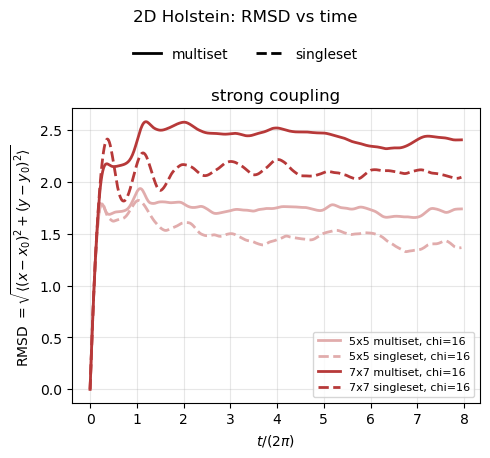

In [4]:
rmsd_runs = [run for run in runs if run.time is not None and run.occupations is not None]
couplings_present = [c for c in COUPLINGS if any(run.meta.coupling == c for run in rmsd_runs)]

if not rmsd_runs:
    print("No occupation data found for RMSD.")
else:
    fig, axes = plt.subplots(1, len(couplings_present), figsize=(5.0 * len(couplings_present), 4.2), sharey=True, squeeze=False)
    axes = axes.ravel()
    for ax, coupling in zip(axes, couplings_present):
        coupling_runs = [run for run in rmsd_runs if run.meta.coupling == coupling]
        sizes = sorted({run.meta.size for run in coupling_runs})
        colors = color_shades(COUPLING_BASE_COLORS[coupling], sizes)
        for size in sizes:
            for method in METHODS:
                candidates = [run for run in coupling_runs if run.meta.size == size and run.meta.method == method]
                if not candidates:
                    continue
                run = candidates[0]
                try:
                    rmsd = compute_rmsd_2d(run.occupations, run.meta.size)
                except ValueError as exc:
                    warnings.warn(f"skip RMSD for {run.meta.path}: {exc}")
                    continue
                n = min(len(run.time), len(rmsd))
                chi = "" if run.meta.bond_dim is None else f", chi={run.meta.bond_dim}"
                ax.plot(
                    plot_time(run.time[:n]),
                    rmsd[:n],
                    color=colors[size],
                    linestyle=method_linestyle(method),
                    linewidth=2.0,
                    label=f"{size}x{size} {method_label(method)}{chi}",
                )
        ax.set_title(COUPLING_LABELS.get(coupling, coupling))
        ax.set_xlabel(r"$t/(2\pi)$")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(r"RMSD $=\sqrt{\langle (x-x_0)^2+(y-y_0)^2\rangle}$")
    handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="multiset"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="singleset"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
    for ax in axes:
        ax.legend(fontsize=8, loc="best")
    fig.suptitle("2D Holstein: RMSD vs time", y=1.08)
    fig.tight_layout()
    maybe_save(fig, "2d_holstein_rmsd.png")
    plt.show()


In [5]:
# Coupling-specific RMSD convergence check: chi=16 and chi=32.
SIZE_BASE_COLORS = {
    5: "#1f77b4",
    7: "#d62728",
    9: "#2ca02c",
    11: "#9467bd",
    15: "#8c564b",
}


def bond_dim_shades_for_size(size, bond_dims):
    base = np.array(to_rgb(SIZE_BASE_COLORS.get(size, f"C{len(SIZE_BASE_COLORS)}")))
    bond_dims = sorted(bond_dims)
    if len(bond_dims) == 1:
        weights = [0.15]
    else:
        # Large light-to-dark separation: low chi is pale, high chi is close to the base color.
        weights = np.linspace(0.68, 0.0, len(bond_dims))
    return {
        bd: to_hex(base * (1 - w) + np.ones(3) * w)
        for bd, w in zip(bond_dims, weights)
    }


def plot_coupling_rmsd_convergence(coupling, bond_dims=(16, 32,64)):
    saved_target_bond_dims = TARGET_BOND_DIMS
    try:
        globals()["TARGET_BOND_DIMS"] = list(bond_dims)
        records = [
            meta for meta in discover_run_files(BASE_DIR)
            if meta.coupling == coupling and meta.bond_dim in bond_dims
        ]
    finally:
        globals()["TARGET_BOND_DIMS"] = saved_target_bond_dims

    selected_runs = [
        run for run in (load_run(meta) for meta in records)
        if run is not None and run.time is not None and run.occupations is not None
    ]
    if not selected_runs:
        print(f"No {coupling} chi={list(bond_dims)} occupation data found.")
        return pd.DataFrame()

    sizes = sorted({run.meta.size for run in selected_runs})
    shades = {
        size: bond_dim_shades_for_size(size, {run.meta.bond_dim for run in selected_runs if run.meta.size == size})
        for size in sizes
    }
    method_styles = {"multiset": "-", "singleset": "--"}
    fig, ax = plt.subplots(figsize=(8.4, 5.2))
    plotted = []

    for size in sizes:
        for method in METHODS:
            for bond_dim in sorted(bond_dims):
                candidates = [
                    run for run in selected_runs
                    if run.meta.size == size
                    and run.meta.method == method
                    and run.meta.bond_dim == bond_dim
                ]
                if not candidates:
                    continue
                run = candidates[0]
                try:
                    rmsd = compute_rmsd_2d(run.occupations, run.meta.size)
                except ValueError as exc:
                    warnings.warn(f"skip RMSD for {run.meta.path}: {exc}")
                    continue
                n = min(len(run.time), len(rmsd))
                ax.plot(
                    plot_time(run.time[:n]),
                    rmsd[:n],
                    color=shades[size][bond_dim],
                    linestyle=method_styles[method],
                    linewidth=2.3,
                    label=f"{size}x{size} {method_label(method)} chi={bond_dim}",
                )
                plotted.append({
                    "coupling": coupling,
                    "size": f"{size}x{size}",
                    "method": method,
                    "bond_dim": bond_dim,
                    "path": str(run.meta.path.relative_to(BASE_DIR)),
                })

    if plotted:
        label = COUPLING_LABELS.get(coupling, coupling)
        ax.set_title(f"{label}: RMSD convergence, chi=16 vs chi=32")
        ax.set_xlabel(r"$t/(2\pi)$")
        ax.set_ylabel(r"RMSD $=\sqrt{\langle (x-x_0)^2+(y-y_0)^2\rangle}$")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, ncol=2)
        fig.tight_layout()
        maybe_save(fig, f"{coupling}_rmsd_chi16_chi32.png")
        plt.show()
        plotted_df = pd.DataFrame(plotted)
        display(plotted_df)
        return plotted_df

    print(f"No {coupling} chi={list(bond_dims)} RMSD curves could be plotted.")
    return pd.DataFrame()



In [6]:
weak_convergence = plot_coupling_rmsd_convergence("weakcoupling")

No weakcoupling chi=[16, 32, 64] occupation data found.


In [7]:
# Intermediate coupling convergence check: RMSD for chi=16 and chi=32.
intermediate_convergence = plot_coupling_rmsd_convergence("intermediatecoupling")


No intermediatecoupling chi=[16, 32, 64] occupation data found.


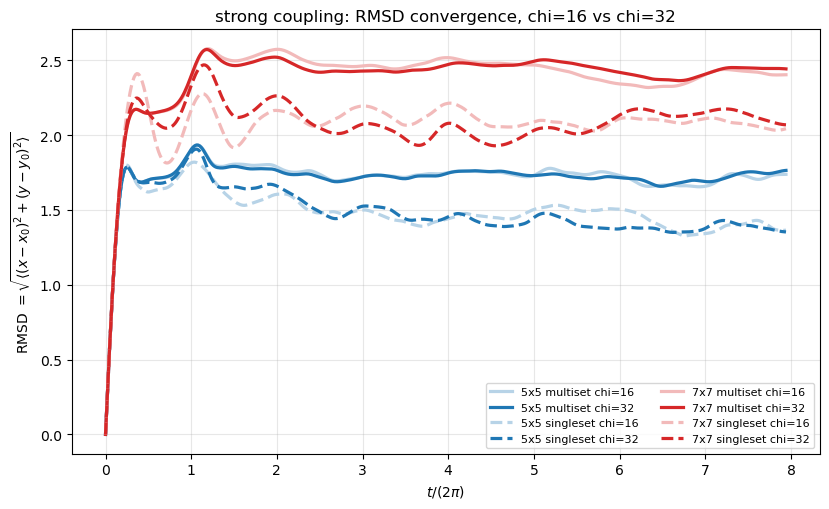

,coupling,size,method,bond_dim,path
0,strongcoupling,5x5,multiset,16,strongcoupling/Holstein_2D55/multiset/H55_2D_m...
1,strongcoupling,5x5,multiset,32,strongcoupling/Holstein_2D55/multiset/H55_2D_m...
2,strongcoupling,5x5,singleset,16,strongcoupling/Holstein_2D55/singleset/H55_2D_...
3,strongcoupling,5x5,singleset,32,strongcoupling/Holstein_2D55/singleset/H55_2D_...
4,strongcoupling,7x7,multiset,16,strongcoupling/Holstein_2D77/multiset/H77_2D_m...
5,strongcoupling,7x7,multiset,32,strongcoupling/Holstein_2D77/multiset/H77_2D_m...
6,strongcoupling,7x7,singleset,16,strongcoupling/Holstein_2D77/singleset/H77_2D_...
7,strongcoupling,7x7,singleset,32,strongcoupling/Holstein_2D77/singleset/H77_2D_...


In [8]:
# Strong coupling convergence check: RMSD for chi=16 and chi=32.
strong_convergence = plot_coupling_rmsd_convergence("strongcoupling")


compare data roots:
  mu64: /curie-home/zengjj/Renormalizer/multiset_202606/2DHolstein_mu64
  mu8: /curie-home/zengjj/Renormalizer/multiset_202606/2DHolstein


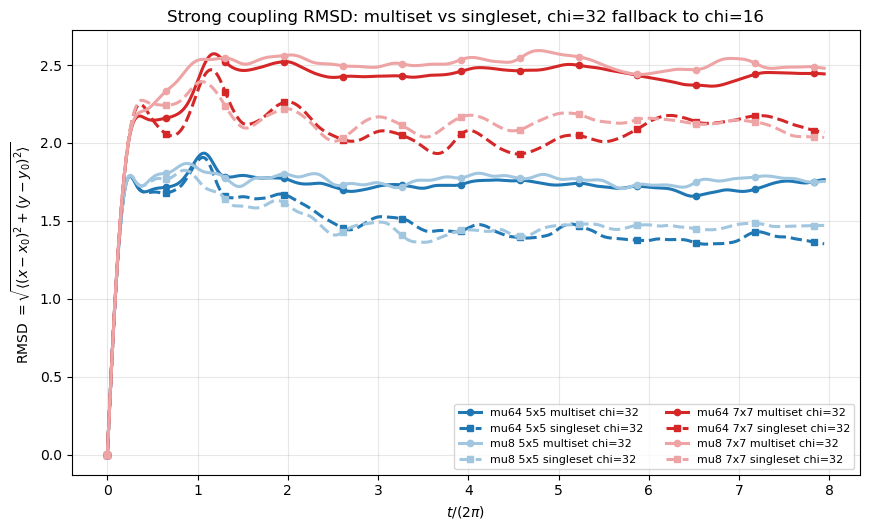

,mu,size,method,bond_dim,path
0,mu64,5x5,multiset,32,/curie-home/zengjj/Renormalizer/multiset_20260...
1,mu64,5x5,singleset,32,/curie-home/zengjj/Renormalizer/multiset_20260...
2,mu8,5x5,multiset,32,/curie-home/zengjj/Renormalizer/multiset_20260...
3,mu8,5x5,singleset,32,/curie-home/zengjj/Renormalizer/multiset_20260...
4,mu64,7x7,multiset,32,/curie-home/zengjj/Renormalizer/multiset_20260...
5,mu64,7x7,singleset,32,/curie-home/zengjj/Renormalizer/multiset_20260...
6,mu8,7x7,multiset,32,/curie-home/zengjj/Renormalizer/multiset_20260...
7,mu8,7x7,singleset,32,/curie-home/zengjj/Renormalizer/multiset_20260...


In [10]:
# Compare multiset and singleset RMSD for mu=64 and mu=8.
# For each mu/size/method, use chi=32 when available; otherwise fall back to chi=16.
# Both current names (H55_2D_m32.npz) and older names (H55_m32.npz) are supported.
mu64_base = BASE_DIR.resolve()
mu8_base = (mu64_base.parent / "2DHolstein").resolve()
compare_bases = {
    "mu64": mu64_base,
    "mu8": mu8_base,
}
compare_coupling = "strongcoupling"
compare_sizes = [5, 7]
compare_methods = ["multiset", "singleset"]
preferred_bond_dims = [32, 16]
method_prefix = {"multiset": "m", "singleset": "s"}

print("compare data roots:")
for mu_label, base in compare_bases.items():
    print(f"  {mu_label}: {base}")

def compare_npz_names(size, method, bond_dim):
    token = f"{size}{size}"
    prefix = method_prefix[method]
    return [
        f"H{token}_2D_{prefix}{bond_dim}.npz",
        f"H{token}_{prefix}{bond_dim}.npz",
    ]

def find_compare_npz(base, size, method, bond_dim):
    token = f"{size}{size}"
    run_dir = base / compare_coupling / f"Holstein_2D{token}" / method
    for name in compare_npz_names(size, method, bond_dim):
        direct = run_dir / name
        if direct.exists():
            return direct

    search_root = base / compare_coupling
    if not search_root.exists():
        return None

    for name in compare_npz_names(size, method, bond_dim):
        matches = sorted(
            path for path in search_root.rglob(name)
            if f"Holstein_2D{token}" in path.parts and method in path.parts
        )
        if matches:
            return matches[0]
    return None

def select_compare_npz(base, size, method):
    for bond_dim in preferred_bond_dims:
        path = find_compare_npz(base, size, method, bond_dim)
        if path is not None:
            return bond_dim, path
    return None, None

def load_compare_rmsd(path, size):
    with np.load(path, allow_pickle=True) as data:
        time = np.asarray(data["time_series"], dtype=float)
        occupations = np.asarray(np.real_if_close(data["e_occupations"]), dtype=float)
    return plot_time(time), compute_rmsd_2d(occupations, size)

size_base_colors = {5: "#1f77b4", 7: "#d62728"}
mu_shade_weights = {"mu64": 0.0, "mu8": 0.58}
method_styles = {"multiset": "-", "singleset": "--"}
method_markers = {"multiset": "o", "singleset": "s"}
fig, ax = plt.subplots(figsize=(8.8, 5.4))
plotted = []

for size in compare_sizes:
    base_rgb = np.array(to_rgb(size_base_colors[size]))
    for mu_label, base in compare_bases.items():
        shade = mu_shade_weights[mu_label]
        color = to_hex(base_rgb * (1 - shade) + np.ones(3) * shade)
        for method in compare_methods:
            bond_dim, path = select_compare_npz(base, size, method)
            if path is None:
                print(f"[skip] missing {mu_label} {size}x{size} {method} chi=32/16")
                continue
            time, rmsd = load_compare_rmsd(path, size)
            ax.plot(
                time,
                rmsd,
                color=color,
                linestyle=method_styles[method],
                linewidth=2.2,
                marker=method_markers[method],
                markevery=max(1, len(time) // 12),
                markersize=4.5,
                label=f"{mu_label} {size}x{size} {method} chi={bond_dim}",
            )
            plotted.append({
                "mu": mu_label,
                "size": f"{size}x{size}",
                "method": method,
                "bond_dim": bond_dim,
                "path": str(path),
            })

ax.set_title("Strong coupling RMSD: multiset vs singleset, chi=32 fallback to chi=16")
ax.set_xlabel(r"$t/(2\pi)$")
ax.set_ylabel(r"RMSD $=\sqrt{\langle (x-x_0)^2+(y-y_0)^2\rangle}$")
ax.grid(True, alpha=0.3)
if plotted:
    ax.legend(fontsize=8, ncol=2)
else:
    ax.text(0.5, 0.5, "No matching data found", transform=ax.transAxes, ha="center", va="center")
fig.tight_layout()
plt.show()
display(pd.DataFrame(plotted))
